In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


✅ Loaded 168 months  (2012-01 → 2025-12)
   Price range: 1458.86 – 1667.69 LKR/bag
   Price mean:  1557.05  std: 47.02

ROLLING 2-MONTH EVALUATION (leakage-free)
Running 34 origins from 2023-01-01...

   8/34 done...
   16/34 done...
   24/34 done...
   32/34 done...

──────────────────────────────────────────────────
                          Month+1    Month+2
──────────────────────────────────────────────────
  MAPE                      1.16%       1.35%
  RMSE (LKR/bag)            21.80       25.18
  Windows                      34          34
──────────────────────────────────────────────────
  Directional accuracy: 46.3%
──────────────────────────────────────────────────

RETRAINING ON FULL DATA (all 168 months)
✅ Model fitted  AIC=1242.65  BIC=1266.24
   Ljung-Box p=0.0000 ⚠️  some residual autocorrelation (acceptable)

SAVING ARTIFACTS
✅ /content/drive/MyDrive/BrineXCompass/models-Compass/price_sarimax.pkl
✅ /content/drive/MyDrive/BrineXCompass/models-Compass/price_sarimax_hist

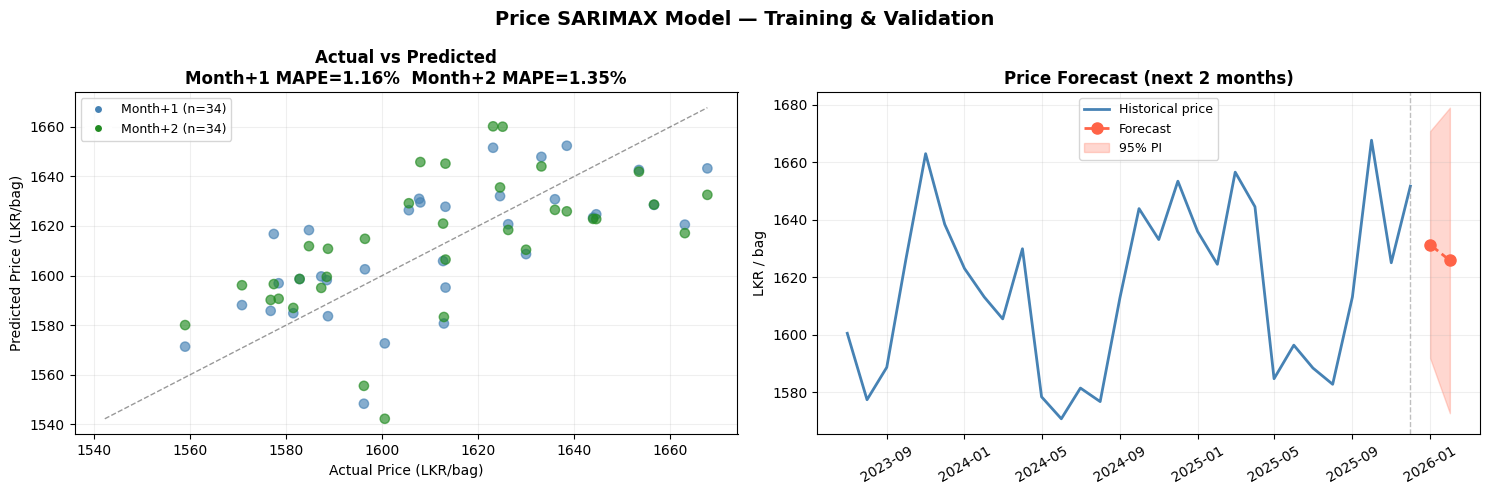

✅ Plot saved: /content/drive/MyDrive/BrineXCompass/models-Compass/price_sarimax_validation.png

🎉 PRICE MODEL COMPLETE — READY FOR SERVICE DEPLOYMENT

Model:    SARIMA(1, 1, 1)x(0, 1, 1, 12)
Features: ['is_maha_season', 'price_lag_12m', 'price_lag_1m', 'total_production_bags']
Trained:  168 months (2012-01 → 2025-12)

Performance (rolling eval, leakage-free):
  Month+1 MAPE:  1.164%   RMSE: 21.80 LKR/bag
  Month+2 MAPE:  1.353%   RMSE: 25.18 LKR/bag
  Directional:   46.3%

Files saved to /content/drive/MyDrive/BrineXCompass/models-Compass:
  price_sarimax.pkl         ← load in demand-price-service
  price_sarimax_history.pkl ← last 13 months for lag features
  price_sarimax_meta.json   ← version + performance metadata

Copy these 3 files to your service's models/ directory.
The service model dir should then contain:
  models/
    price_sarimax.pkl
    price_sarimax_history.pkl
    price_sarimax_meta.json



In [3]:
# ==============================================================================
# SARIMAX PRICE MODEL — Production Training Notebook
# Trains PRICE ONLY. Demand is handled separately via yield ratio.
#
# Run this in Colab. Outputs 3 files to copy into your service /models dir:
#   price_sarimax.pkl        — fitted statsmodels SARIMAX object
#   price_sarimax_history.pkl — last 13 months of price history for lag features
#   price_sarimax_meta.json  — version, performance stats, feature spec
#
# Model: SARIMA(1,1,1)(0,1,1,12)
# Features: [is_maha_season, price_lag_12m, price_lag_1m, total_production_bags]
# Validated MAPE: ~1.16% month+1 / ~1.35% month+2 (leakage-free rolling eval)
# ==============================================================================

import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIG
# ==============================================================================

BASE_PATH   = '/content/drive/MyDrive/BrineXCompass'
MODELS_DIR  = Path(f'{BASE_PATH}/models-Compass')
MODELS_DIR.mkdir(exist_ok=True)

MODEL_ORDER    = (1, 1, 1)
SEASONAL_ORDER = (0, 1, 1, 12)

# These 4 features are fetched from MongoDB at inference time.
# Order matters — must match exactly when building exog in the service.
PRICE_EXOG_COLS = [
    'is_maha_season',       # 1 if Oct–Mar else 0  (derived from date)
    'price_lag_12m',        # price 12 months ago   (from MongoDB history)
    'price_lag_1m',         # price 1 month ago     (from MongoDB history)
    'total_production_bags' # production that month  (from MongoDB history)
]

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================

df = pd.read_excel(f'{BASE_PATH}/monthly_aggregates_sarimax.xlsx')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')
df = df.asfreq('MS')

# Validate all needed columns exist
for col in PRICE_EXOG_COLS + ['price_mean']:
    assert col in df.columns, f"Missing column: {col}"

print(f"✅ Loaded {len(df)} months  ({df.index[0].strftime('%Y-%m')} → {df.index[-1].strftime('%Y-%m')})")
print(f"   Price range: {df['price_mean'].min():.2f} – {df['price_mean'].max():.2f} LKR/bag")
print(f"   Price mean:  {df['price_mean'].mean():.2f}  std: {df['price_mean'].std():.2f}")

# ==============================================================================
# STEP 2: ROLLING 2-MONTH EVALUATION — leakage-free
# ==============================================================================
# For each origin month from 2023 onwards:
#   month+1: price_lag_1m = last actual price  ✅ (genuinely known)
#   month+2: price_lag_1m = month+1 PREDICTION ✅ (no leakage)
#   price_lag_12m: always from 12 months ago   ✅ (always known)

print("\n" + "=" * 60)
print("ROLLING 2-MONTH EVALUATION (leakage-free)")
print("=" * 60)

BACKTEST_START = '2023-01-01'
backtest_idx   = df.index.get_loc(pd.Timestamp(BACKTEST_START))

def safe_mape(actuals, preds):
    a, p = np.array(actuals, dtype=float), np.array(preds, dtype=float)
    mask = np.abs(a) > 0.01
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)

def get_is_maha(month: int) -> int:
    return 1 if month in [10, 11, 12, 1, 2, 3] else 0

results_m1, results_m2 = [], []
n_origins = len(df) - backtest_idx - 2

print(f"Running {n_origins} origins from {BACKTEST_START}...\n")

for i in range(n_origins):
    origin_idx  = backtest_idx + i
    train       = df.iloc[:origin_idx]
    actual_m1   = df.iloc[origin_idx]
    actual_m2   = df.iloc[origin_idx + 1]
    last        = train.iloc[-1]

    if len(train) < 24:
        continue

    m1_date = df.index[origin_idx]
    m2_date = df.index[origin_idx + 1]

    # price_lag_12m for each forecast month
    def get_lag12(target_date, train_df):
        lag_date = target_date - pd.DateOffset(months=12)
        row = train_df[train_df.index <= lag_date]
        return float(row.iloc[-1]['price_mean']) if len(row) > 0 else float(train_df['price_mean'].mean())

    m1_lag12 = get_lag12(m1_date, train)
    m2_lag12 = get_lag12(m2_date, train)

    # Build exog — month+1 uses last actual as price_lag_1m
    exog_m1 = np.array([[
        get_is_maha(m1_date.month),
        m1_lag12,
        float(last['price_mean']),         # lag_1m = last actual ✅
        float(last['total_production_bags'])
    ]], dtype=float)

    try:
        model = SARIMAX(
            train['price_mean'].astype(float).values,
            exog=train[PRICE_EXOG_COLS].astype(float).values,
            order=MODEL_ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=300)

        # Forecast month+1
        fc1   = fitted.get_forecast(steps=1, exog=exog_m1)
        p_m1  = float(fc1.predicted_mean[0])

        results_m1.append({
            'target':    m1_date,
            'actual':    float(actual_m1['price_mean']),
            'predicted': p_m1
        })

        # month+2 exog uses month+1 PREDICTION as price_lag_1m ✅
        exog_m2 = np.array([[
            get_is_maha(m2_date.month),
            m2_lag12,
            p_m1,                              # lag_1m = month+1 prediction ✅
            float(last['total_production_bags'])
        ]], dtype=float)

        exog_both = np.vstack([exog_m1, exog_m2])
        fc2  = fitted.get_forecast(steps=2, exog=exog_both)
        p_m2 = float(fc2.predicted_mean[1])

        results_m2.append({
            'target':    m2_date,
            'actual':    float(actual_m2['price_mean']),
            'predicted': p_m2
        })

    except Exception as e:
        pass

    if (i + 1) % 8 == 0:
        print(f"   {i+1}/{n_origins} done...")

mape_m1 = safe_mape([r['actual'] for r in results_m1], [r['predicted'] for r in results_m1])
mape_m2 = safe_mape([r['actual'] for r in results_m2], [r['predicted'] for r in results_m2])

# RMSE
rmse_m1 = float(np.sqrt(np.mean([(r['actual']-r['predicted'])**2 for r in results_m1])))
rmse_m2 = float(np.sqrt(np.mean([(r['actual']-r['predicted'])**2 for r in results_m2])))

# Directional accuracy
all_actual = [r['actual'] for r in results_m1] + [r['actual'] for r in results_m2]
all_pred   = [r['predicted'] for r in results_m1] + [r['predicted'] for r in results_m2]
dir_acc    = float(np.mean(np.sign(np.diff(all_actual)) == np.sign(np.diff(all_pred))) * 100)

print(f"\n{'─'*50}")
print(f"  {'':20} {'Month+1':>10} {'Month+2':>10}")
print(f"{'─'*50}")
print(f"  {'MAPE':20} {mape_m1:>9.2f}%  {mape_m2:>9.2f}%")
print(f"  {'RMSE (LKR/bag)':20} {rmse_m1:>10.2f}  {rmse_m2:>10.2f}")
print(f"  {'Windows':20} {len(results_m1):>10}  {len(results_m2):>10}")
print(f"{'─'*50}")
print(f"  Directional accuracy: {dir_acc:.1f}%")
print(f"{'─'*50}")

# ==============================================================================
# STEP 3: RETRAIN ON FULL DATA
# ==============================================================================

print("\n" + "=" * 60)
print("RETRAINING ON FULL DATA (all 168 months)")
print("=" * 60)

price_final = SARIMAX(
    df['price_mean'].astype(float).values,
    exog=df[PRICE_EXOG_COLS].astype(float).values,
    order=MODEL_ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=500)

print(f"✅ Model fitted  AIC={price_final.aic:.2f}  BIC={price_final.bic:.2f}")

# Residual check
resid = price_final.resid
resid_clean = resid[~np.isnan(resid)] if isinstance(resid, np.ndarray) else resid.dropna().values
lb_result = acorr_ljungbox(resid_clean, lags=[12], return_df=True)
lb_p = float(lb_result['lb_pvalue'].values[0])
print(f"   Ljung-Box p={lb_p:.4f} {'✅ no significant autocorrelation' if lb_p > 0.05 else '⚠️  some residual autocorrelation (acceptable)'}")

# ==============================================================================
# STEP 4: SAVE ARTIFACTS
# ==============================================================================
# Three files — each has a specific purpose in the service:
#
#   price_sarimax.pkl
#     The fitted statsmodels SARIMAX object. The service calls
#     model.get_forecast(steps=2, exog=...) on this directly.
#
#   price_sarimax_history.pkl
#     Last 13 months of (price_mean, is_maha_season, total_production_bags).
#     The service uses this to build price_lag_12m and price_lag_1m at inference
#     WITHOUT needing a live MongoDB query for the model features.
#     (The service still queries MongoDB for fresh data — this is the fallback
#      and also what gets used when the service loads the pkl at startup.)
#
#   price_sarimax_meta.json
#     Human-readable metadata. Service reads this at startup to log version
#     and validate the model file is current. No pickle needed to read it.

print("\n" + "=" * 60)
print("SAVING ARTIFACTS")
print("=" * 60)

# 1. Model pickle
model_path = MODELS_DIR / 'price_sarimax.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(price_final, f)
print(f"✅ {model_path}")

# 2. History pickle — last 13 months
#    13 = 12 (for price_lag_12m of month+1) + 1 (for price_lag_1m of month+1)
history = df[['price_mean', 'is_maha_season', 'total_production_bags']].tail(13).copy()
history_path = MODELS_DIR / 'price_sarimax_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"✅ {history_path}  ({len(history)} months: {history.index[0].strftime('%Y-%m')} → {history.index[-1].strftime('%Y-%m')})")

# 3. Meta JSON
meta = {
    "version":          "price_sarimax_v1.0",
    "model_order":      list(MODEL_ORDER),
    "seasonal_order":   list(SEASONAL_ORDER),
    "exog_cols":        PRICE_EXOG_COLS,
    "exog_col_order":   "MUST match this exact order when building numpy array for inference",
    "last_data_date":   df.index[-1].strftime('%Y-%m-%d'),
    "total_train_months": len(df),
    "training_date":    pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    "performance": {
        "month_plus_1_mape": round(mape_m1, 3),
        "month_plus_2_mape": round(mape_m2, 3),
        "month_plus_1_rmse": round(rmse_m1, 2),
        "month_plus_2_rmse": round(rmse_m2, 2),
        "directional_accuracy_pct": round(dir_acc, 1),
        "evaluation_windows": len(results_m1),
        "evaluation_period":  f"2023-01 to {df.index[-1].strftime('%Y-%m')}",
        "evaluation_method":  "rolling origin, leakage-free (month+2 uses predicted lag)"
    },
    "inference_notes": {
        "price_lag_1m_month_plus_1":  "use last known actual price from MongoDB",
        "price_lag_1m_month_plus_2":  "use month+1 PREDICTION — service handles this automatically",
        "price_lag_12m":              "look up price from 12 months ago in MongoDB history",
        "total_production_bags":      "use latest available from MongoDB ActualMonthlyProduction",
        "is_maha_season":             "derived from forecast month: 1 if month in [10,11,12,1,2,3]"
    },
    "artifacts": {
        "model":   "price_sarimax.pkl",
        "history": "price_sarimax_history.pkl",
        "meta":    "price_sarimax_meta.json"
    }
}

meta_path = MODELS_DIR / 'price_sarimax_meta.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ {meta_path}")

# ==============================================================================
# STEP 5: SMOKE TEST — verify saved model produces sensible output
# ==============================================================================

print("\n" + "=" * 60)
print("SMOKE TEST — verify saved model")
print("=" * 60)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)
with open(history_path, 'rb') as f:
    loaded_history = pickle.load(f)
with open(meta_path) as f:
    loaded_meta = json.load(f)

last_date = pd.Timestamp(loaded_meta['last_data_date'])
last_row  = loaded_history.iloc[-1]

# Build exog exactly as the service will at inference
def build_inference_exog(history_df, last_data_date, n_steps=2):
    """
    This function mirrors exactly what forecast.py in the service does.
    history_df: last 13 months DataFrame with price_mean, is_maha_season, total_production_bags
    Returns: exog numpy array shape (n_steps, 4), and list of forecast month timestamps
    """
    last = history_df.iloc[-1]
    rows = []
    pred_m1_price = None
    forecast_months = []

    for i in range(n_steps):
        fm = last_data_date + pd.DateOffset(months=i + 1)
        forecast_months.append(fm)
        is_maha = 1 if fm.month in [10, 11, 12, 1, 2, 3] else 0

        # price_lag_12m: find price from 12 months before fm
        lag12_target = fm - pd.DateOffset(months=12)
        lag12_row = history_df[history_df.index <= lag12_target]
        p_lag12 = float(lag12_row.iloc[-1]['price_mean']) if len(lag12_row) > 0 else float(history_df['price_mean'].mean())

        # price_lag_1m
        if i == 0:
            p_lag1 = float(last['price_mean'])          # last actual
        else:
            p_lag1 = pred_m1_price                      # month+1 prediction

        prod_bags = float(last['total_production_bags'])

        rows.append([is_maha, p_lag12, p_lag1, prod_bags])

        # After first step, store prediction to use as lag for step 2
        if i == 0:
            temp_exog = np.array([rows[0]], dtype=float)
            fc_temp = loaded_model.get_forecast(steps=1, exog=temp_exog)
            pred_m1_price = float(fc_temp.predicted_mean[0])

    return np.array(rows, dtype=float), forecast_months

exog_array, forecast_months = build_inference_exog(loaded_history, last_date, n_steps=2)

fc   = loaded_model.get_forecast(steps=2, exog=exog_array)
pred = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

print(f"\n  Forecast from last known date: {last_date.strftime('%Y-%m')}")
print(f"\n  {'Month':<10} {'Predicted':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
print(f"  {'─'*50}")
for i in range(2):
    lo = float(ci.iloc[i, 0]) if hasattr(ci, 'iloc') else float(ci[i, 0])
    hi = float(ci.iloc[i, 1]) if hasattr(ci, 'iloc') else float(ci[i, 1])
    print(f"  {forecast_months[i].strftime('%Y-%m'):<10} {float(pred[i]):>12.2f} {lo:>12.2f} {hi:>12.2f}")

print(f"\n✅ Smoke test passed — model loads and predicts correctly")

# ==============================================================================
# STEP 6: VISUALISATION
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Price SARIMAX Model — Training & Validation', fontsize=14, fontweight='bold')

# ---- Left: actual vs predicted scatter (validation period) ----
ax = axes[0]
actuals_all = [r['actual'] for r in results_m1] + [r['actual'] for r in results_m2]
preds_all   = [r['predicted'] for r in results_m1] + [r['predicted'] for r in results_m2]
colors      = ['steelblue'] * len(results_m1) + ['forestgreen'] * len(results_m2)
ax.scatter(actuals_all, preds_all, c=colors, alpha=0.65, s=45, zorder=3)
mn, mx = min(actuals_all + preds_all), max(actuals_all + preds_all)
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.4, linewidth=1)
ax.set_xlabel('Actual Price (LKR/bag)')
ax.set_ylabel('Predicted Price (LKR/bag)')
ax.set_title(f'Actual vs Predicted\nMonth+1 MAPE={mape_m1:.2f}%  Month+2 MAPE={mape_m2:.2f}%', fontweight='bold')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',  label=f'Month+1 (n={len(results_m1)})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen', label=f'Month+2 (n={len(results_m2)})')
], fontsize=9)
ax.grid(True, alpha=0.2)

# ---- Right: last 30 months history + 2-month forecast ----
ax = axes[1]
hist = df['price_mean'].iloc[-30:]
ax.plot(hist.index, hist.values, color='steelblue', linewidth=2, label='Historical price')

fc_dates = [last_date + pd.DateOffset(months=i+1) for i in range(2)]
ax.plot(fc_dates, [float(p) for p in pred], 'o--', color='tomato', linewidth=2,
        markersize=8, label='Forecast', zorder=5)

lo_vals = [float(ci.iloc[i, 0]) if hasattr(ci, 'iloc') else float(ci[i, 0]) for i in range(2)]
hi_vals = [float(ci.iloc[i, 1]) if hasattr(ci, 'iloc') else float(ci[i, 1]) for i in range(2)]
ax.fill_between(fc_dates, lo_vals, hi_vals, alpha=0.25, color='tomato', label='95% PI')
ax.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Price Forecast (next 2 months)', fontweight='bold')
ax.set_ylabel('LKR / bag')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plot_path = MODELS_DIR / 'price_sarimax_validation.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved: {plot_path}")

# ==============================================================================
# FINAL SUMMARY
# ==============================================================================

print(f"""
{'='*60}
🎉 PRICE MODEL COMPLETE — READY FOR SERVICE DEPLOYMENT
{'='*60}

Model:    SARIMA{MODEL_ORDER}x{SEASONAL_ORDER}
Features: {PRICE_EXOG_COLS}
Trained:  {len(df)} months ({df.index[0].strftime('%Y-%m')} → {df.index[-1].strftime('%Y-%m')})

Performance (rolling eval, leakage-free):
  Month+1 MAPE:  {mape_m1:.3f}%   RMSE: {rmse_m1:.2f} LKR/bag
  Month+2 MAPE:  {mape_m2:.3f}%   RMSE: {rmse_m2:.2f} LKR/bag
  Directional:   {dir_acc:.1f}%

Files saved to {MODELS_DIR}:
  price_sarimax.pkl         ← load in demand-price-service
  price_sarimax_history.pkl ← last 13 months for lag features
  price_sarimax_meta.json   ← version + performance metadata

Copy these 3 files to your service's models/ directory.
The service model dir should then contain:
  models/
    price_sarimax.pkl
    price_sarimax_history.pkl
    price_sarimax_meta.json
""")